In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
df_index=pd.read_csv("/content/economic_dataset.csv")

In [ ]:
df_index.head()

,interest_rate,unemployment_rate,index_price
0,2.5,5.1,1550
1,2.7,5.3,1580
2,2.9,5.4,1605
3,3.0,5.2,1620
4,3.1,5.5,1630


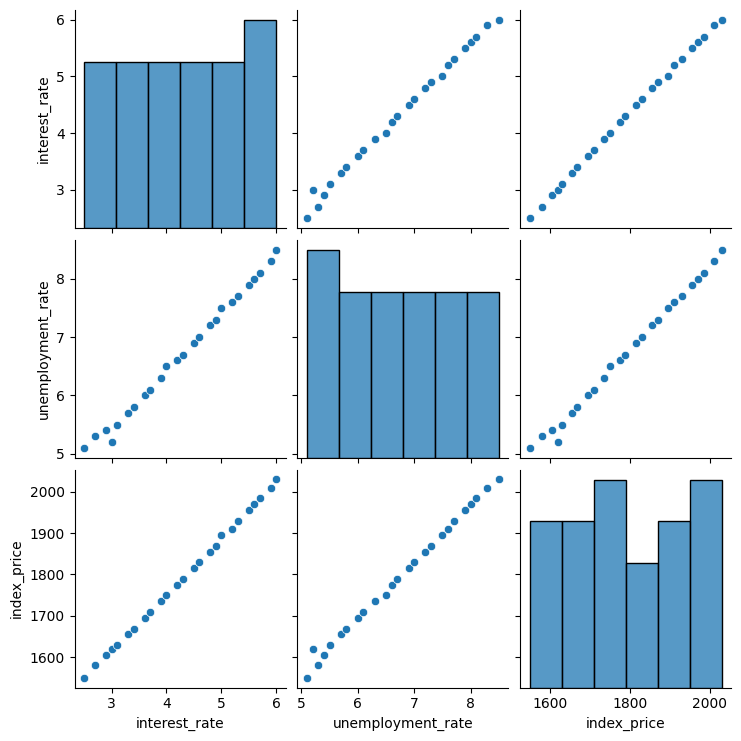

In [ ]:
import seaborn as sns
sns.pairplot(df_index)

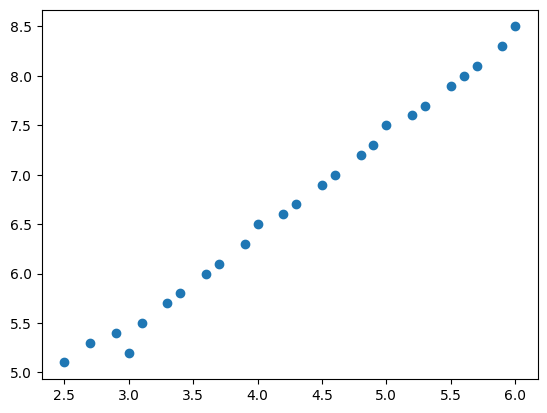

In [ ]:
plt.scatter(df_index['interest_rate'],df_index['unemployment_rate'])

In [ ]:
df_index.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,0.997368,0.999685
unemployment_rate,0.997368,1.000000,0.997667
index_price,0.999685,0.997667,1.000000


In [ ]:
X=df_index.iloc[:,:-1]
y=df_index.iloc[:,-1]

In [ ]:
y

,index_price
0,1550
1,1580
2,1605
3,1620
4,1630
5,1655
6,1668
7,1695
8,1710
9,1735


In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [ ]:
X_test.shape

(7, 2)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.fit_transform(X_test)

In [ ]:
X_train

array([[-1.52530338, -1.35585777],
       [ 1.27627425,  1.25235718],
       [-0.96498785, -0.98325564],
       [-1.33853153, -1.26270724],
       [-0.03112864, -0.0517503 ],
       [ 0.43580096,  0.41400237],
       [-1.24514561, -1.4490083 ],
       [-1.15175969, -1.1695567 ],
       [ 1.08950241,  1.06605611],
       [ 0.62257281,  0.69345397],
       [ 1.18288833,  1.15920664],
       [ 0.80934465,  0.78660451],
       [ 1.55643202,  1.62495931],
       [-0.68483009, -0.70380403],
       [-0.3112864 , -0.23805136],
       [ 0.24902912,  0.22770131],
       [ 0.90273057,  0.87975504],
       [-0.87160193, -0.8901051 ]])

In [ ]:
from sklearn.linear_model import LinearRegression
regression=LinearRegression()
regression.fit(X_train,y_train)

LinearRegression()

In [ ]:
print("Slope:",regression.coef_)
print("Intercept:",regression.intercept_)

Slope: [130.71581221  14.89895778]
Intercept: 1797.2777777777778


In [ ]:
X_test

array([[-0.54050608, -0.59992901],
       [ 0.6865888 ,  0.69222578],
       [-1.76760096, -1.67672466],
       [ 1.70916787,  1.76902143],
       [-0.02921654, -0.06153118],
       [-0.33599026, -0.38456988],
       [ 0.27755718,  0.26150752]])

In [ ]:
y_pred=regression.predict(X_test)

<Axes: xlabel='interest_rate', ylabel='index_price'>

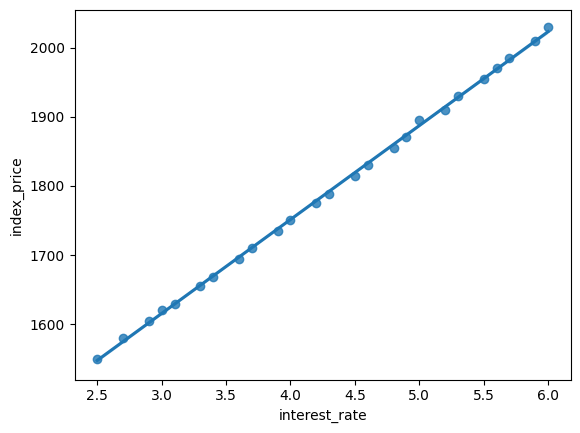

In [ ]:
sns.regplot(x=df_index['interest_rate'], y=df_index['index_price'])

In [ ]:
from sklearn.metrics import mean_squared_error,mean_absolute_error
print("MSE:",mean_squared_error(y_test,y_pred))
print("MAE:",mean_absolute_error(y_test,y_pred))
print("RMSE:",np.sqrt(mean_squared_error(y_test,y_pred)))

MSE: 461.04563410297584
MAE: 19.0655112024256
RMSE: 21.47197322332011


In [ ]:
from sklearn.metrics import r2_score
r2=r2_score(y_test,y_pred)
print("R squared:",r2_score(y_test,y_pred))

R squared: 0.9735620408764823


In [ ]:
adj_r2=1-(((1-(r2*r2))*(len(y_test)-1))/(len(y_test)-X_test.shape[1]-1))
print("Adjusted R squared:",adj_r2)

Adjusted R squared: 0.9217345711533722


In [ ]:
from sklearn.model_selection import cross_val_score
validation=cross_val_score(regression,X_train,y_train,scoring='neg_mean_squared_error',cv=3)
validation

array([-18.5489806 , -58.3365674 , -15.32248672])

In [ ]:
np.mean(validation)

np.float64(-30.736011574742708)

In [ ]:
import statsmodels.api as sm
model=sm.OLS(y_train,X_train).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:            index_price   R-squared (uncentered):                   0.007
Model:                            OLS   Adj. R-squared (uncentered):             -0.118
Method:                 Least Squares   F-statistic:                            0.05249
Date:                Wed, 10 Dec 2025   Prob (F-statistic):                       0.949
Time:                        04:51:44   Log-Likelihood:                         -160.43
No. Observations:                  18   AIC:                                      324.9
Df Residuals:                      16   BIC:                                      326.6
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1           130.7158   6139.447      0.021      0.983   -1.29e+04    1.31e+04
x2            14.8990   6139.447      0.002      0.998    -1.3e+04     1.3e+04
==============================================================================
Omnibus:                        0.912   Durbin-Watson:                   0.000
Prob(Omnibus):                  0.634   Jarque-Bera (JB):                0.854
Skew:                           0.349   Prob(JB):                        0.653
Kurtosis:                       2.194   Cond. No.                         27.3
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Text(0, 0.5, 'Predicted')

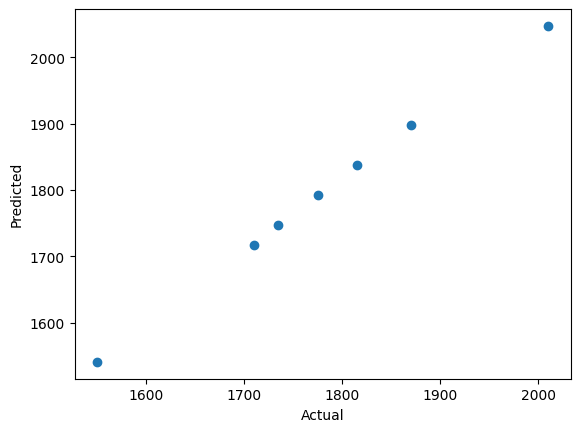

In [ ]:
plt.scatter(y_test,y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")

In [ ]:
residuals=y_test-y_pred
residuals

,index_price
8,-7.686770
16,-27.339233
0,8.757067
23,-37.049619
11,-17.541963
9,-12.628847
13,-22.455079


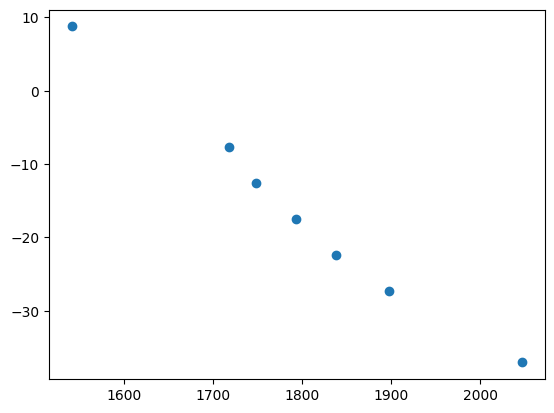

In [ ]:
plt.scatter(y_pred,residuals)

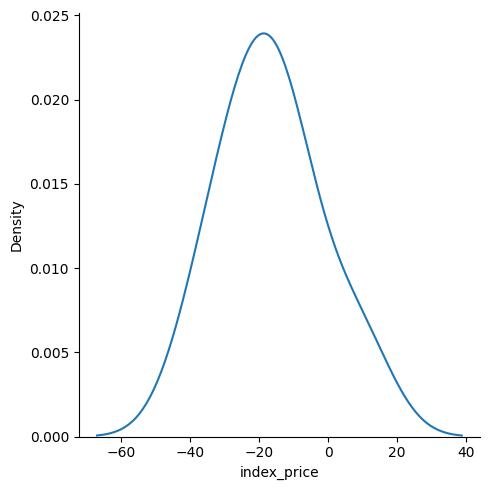

In [ ]:
sns.displot(residuals,kind='kde')